# Dataset Exploration

In [1]:
from pathlib import Path 
Path.cwd()

WindowsPath('c:/Users/kwsta/OneDrive/Desktop/Desetation project/brain-tumour-mri-classification/notebooks')

In [2]:
from pathlib import Path

# creating a path to the data folder
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

print("Project root:", PROJECT_ROOT)
print("Data folder:", DATA_DIR)
print("Data folder exists:", DATA_DIR.exists())

Project root: c:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification
Data folder: c:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification\data
Data folder exists: True


In [3]:
print("Data folder contents:", list(DATA_DIR.iterdir()))

for file in DATA_DIR.iterdir():
    if file.is_file():
        print(f"File: {file.name}, Size: {file.stat().st_size} bytes")
    elif file.is_dir():
        print(f"Directory: {file.name}")


Data folder contents: [WindowsPath('c:/Users/kwsta/OneDrive/Desktop/Desetation project/brain-tumour-mri-classification/data/Testing'), WindowsPath('c:/Users/kwsta/OneDrive/Desktop/Desetation project/brain-tumour-mri-classification/data/Training')]
Directory: Testing
Directory: Training


In [4]:
TRAINING_DIR = DATA_DIR / "Training"

# Check what the training directory contains
for folder in sorted(TRAINING_DIR.iterdir()):
    if folder.is_dir():
        print(folder.name)

glioma
meningioma
notumor
pituitary


In [5]:
# Count the number of images in each class folder
for class_folder in sorted(TRAINING_DIR.iterdir()):
    if class_folder.is_dir():
        image_count = sum(1 for item in class_folder.iterdir() if item.is_file())
        print(f"{class_folder.name}: {image_count} images")

glioma: 1400 images
meningioma: 1400 images
notumor: 1400 images
pituitary: 1400 images


In [6]:
TESTING_DIR = DATA_DIR / "Testing"

# Check what the testing directory contains
for class_folder in sorted(TESTING_DIR.iterdir()):
    if class_folder.is_dir():
        image_count = sum(
            1 for item in class_folder.iterdir()
            if item.is_file()
        )
        print(f"{class_folder.name}: {image_count} images")

glioma: 400 images
meningioma: 400 images
notumor: 400 images
pituitary: 400 images


In [7]:
from collections import Counter

# Count the number of images in each class folder and their file extensions
file_extensions = Counter()

for split_folder in [TRAINING_DIR, TESTING_DIR]:
    for class_folder in split_folder.iterdir():
        if class_folder.is_dir():
            for image_file in class_folder.iterdir():
                if image_file.is_file():
                    file_extensions[image_file.suffix.lower()] += 1

print(file_extensions)

Counter({'.jpg': 7200})


In [8]:
from collections import Counter
from dbm import error
from PIL import Image

image_sizes = Counter()
unreadable_images = []

# Count the number of images in each class folder and their sizes
for split_folder in [TRAINING_DIR, TESTING_DIR]:
    for class_folder in split_folder.iterdir():
        if class_folder.is_dir():
            for image_file in class_folder.iterdir():
                if image_file.is_file():
                    try:
                        with Image.open(image_file) as img:
                            image_sizes[img.size] += 1
                    except Exception as e:
                        print(f"Error opening {image_file}: {e}")
                        unreadable_images.append((image_file, e))
                        
print("Image sizes:", image_sizes)

Image sizes: Counter({(512, 512): 5014, (225, 225): 338, (630, 630): 90, (201, 251): 57, (228, 221): 51, (232, 217): 50, (442, 442): 48, (236, 236): 48, (150, 198): 44, (200, 252): 43, (428, 417): 42, (227, 222): 39, (173, 201): 36, (206, 244): 35, (256, 256): 33, (192, 192): 31, (201, 250): 29, (218, 231): 29, (215, 234): 28, (227, 262): 27, (468, 444): 24, (208, 242): 24, (504, 540): 23, (359, 449): 23, (214, 236): 22, (300, 168): 21, (400, 442): 20, (236, 213): 19, (393, 400): 18, (207, 243): 18, (442, 454): 17, (230, 282): 17, (276, 326): 17, (441, 442): 16, (235, 214): 16, (550, 664): 16, (194, 259): 15, (680, 680): 15, (420, 280): 14, (339, 340): 13, (212, 238): 12, (275, 183): 12, (642, 361): 12, (196, 257): 12, (380, 530): 12, (350, 350): 11, (177, 197): 9, (356, 474): 9, (350, 393): 7, (554, 554): 6, (455, 500): 5, (236, 357): 5, (1024, 1024): 5, (235, 227): 5, (208, 248): 5, (220, 275): 5, (210, 240): 4, (200, 223): 4, (341, 395): 4, (212, 237): 4, (275, 301): 4, (416, 512): 

In [9]:
# Checking for unreadable images
print(f"unreadable_images: {len(unreadable_images)}")

unreadable_images: 0


In [10]:
# Checking how the images are stored in the folders

image_modes = Counter()
for split_folder in [TRAINING_DIR, TESTING_DIR]:
    for class_folder in split_folder.iterdir():
        if class_folder.is_dir():
            for image_file in class_folder.iterdir():
                if image_file.is_file():
                    try:
                        with Image.open(image_file) as img:
                            image_modes[img.mode] += 1
                    except Exception as e:
                        print(f"Error opening {image_file}: {e}")
                        unreadable_images.append((image_file, e))

print("Image modes:", image_modes)

Image modes: Counter({'RGB': 4129, 'L': 3067, 'RGBA': 3, 'P': 1})


In [11]:
# Checking if the MRI images are grayscale images saved as RGB format or if they are actually RGB

import numpy as np

grayscale_rgb_images = [] # List to store RGB images
different_rgb_images = [] # List to check those images that are not grayscale images saved as RGB format

for split_folder in [TRAINING_DIR, TESTING_DIR]:
    for class_folder in split_folder.iterdir():
        if class_folder.is_dir():
            for image_file in class_folder.glob("*.jpg"):  # Assuming images are in .jpg format; adjust as needed
                with Image.open(image_file) as img:
                    if img.mode == 'RGB':
                        
                        # Convert the image to a NumPy array and check if all channels are equal (indicating grayscale)
                        pixels = np.array(img, dtype=np.int16)
                        
                        # For every pixel, check if R == G == B
                        if np.all(pixels[..., 0] == pixels[..., 1]) and np.all(pixels[..., 1] == pixels[..., 2]): # The ... indicates that we are checking all pixels in the image
                            grayscale_rgb_images.append(image_file)
                        else:
                            different_rgb_images.append(image_file)

print(f"Number of grayscale images saved as RGB: {len(grayscale_rgb_images)}")
print(f"Number of different RGB images: {len(different_rgb_images)}")


Number of grayscale images saved as RGB: 4003
Number of different RGB images: 126


In [12]:
# Checking the non-grayscale RGB images to see how large the RGB differences are
channel_difference_results = []
for image_file in different_rgb_images:
    with Image.open(image_file) as img:
        pixels = np.array(img, dtype=np.int16)
        r_channel = pixels[..., 0]
        g_channel = pixels[..., 1]
        b_channel = pixels[..., 2]
        
        # Calculate the absolute differences between channels
        rg_diff = np.abs(r_channel - g_channel)
        rb_diff = np.abs(r_channel - b_channel)
        gb_diff = np.abs(g_channel - b_channel)
        
        # Largest channel difference at each pixel
        pixel_difference = np.maximum.reduce([rg_diff, rb_diff, gb_diff])

        # Overall measurements for the image
        mean_difference = pixel_difference.mean()
        different_pixel_percentage = (pixel_difference > 0).mean() * 100
        
        # Store the maximum differences for each image
        max_rg_diff = np.max(rg_diff)
        max_rb_diff = np.max(rb_diff)
        max_gb_diff = np.max(gb_diff)
        
        channel_difference_results.append({
    "image_file": image_file,
    "max_rg_diff": max_rg_diff,
    "max_rb_diff": max_rb_diff,
    "max_gb_diff": max_gb_diff,
    "mean_difference": mean_difference,
    "different_pixel_percentage": different_pixel_percentage

})
print("Channel difference results for non-grayscale RGB images:")
for result in channel_difference_results:
    print(f"Image: {result['image_file']}, Max RG Diff: {result['max_rg_diff']}, Max RB Diff: {result['max_rb_diff']}, Max GB Diff: {result['max_gb_diff']}, Mean Difference: {result['mean_difference']:.2f}, Different Pixel Percentage: {result['different_pixel_percentage']:.2f}%")


Channel difference results for non-grayscale RGB images:
Image: c:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification\data\Training\notumor\Tr-no_1002.jpg, Max RG Diff: 6, Max RB Diff: 4, Max GB Diff: 2, Mean Difference: 0.18, Different Pixel Percentage: 6.89%
Image: c:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification\data\Training\notumor\Tr-no_1006.jpg, Max RG Diff: 1, Max RB Diff: 7, Max GB Diff: 8, Mean Difference: 0.01, Different Pixel Percentage: 0.15%
Image: c:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification\data\Training\notumor\Tr-no_1013.jpg, Max RG Diff: 12, Max RB Diff: 42, Max GB Diff: 35, Mean Difference: 0.55, Different Pixel Percentage: 2.42%
Image: c:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification\data\Training\notumor\Tr-no_102.jpg, Max RG Diff: 1, Max RB Diff: 6, Max GB Diff: 6, Mean Difference: 3.40, Different Pixel Percentage: 86.21%
Image: c

In [13]:
# Checking to see from which category are the non-grayscale RGB images

anomaly_classes = Counter(path.parent.name for path in different_rgb_images)
print("Anomaly classes (non-grayscale RGB images):", anomaly_classes)


Anomaly classes (non-grayscale RGB images): Counter({'notumor': 126})


In [14]:
# Count how many are in Training vs Testing
split_distribution = Counter(path.parent.parent.name for path in different_rgb_images)
print("Split distribution of non-grayscale images:", split_distribution)

Split distribution of non-grayscale images: Counter({'Training': 88, 'Testing': 38})


Displaying image 1/30: c:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification\data\Testing\notumor\Te-no_297.jpg


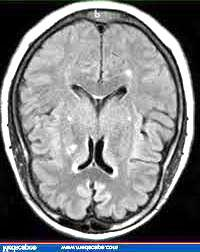

In [16]:
# Inspecting the non-grayscale RGB images with the largest channel differences one by one

# Sort the results by mean_difference in descending order
sorted_results = sorted(channel_difference_results, key=lambda x: x['mean_difference'], reverse=True)

# Pick the top 10 images with the largest mean channel differences to look at
top_n = min(30, len(sorted_results))
top_images = sorted_results[:top_n]


#  Displaying the images with the largest channel differences

from IPython.display import display
image_index = 0  # Change this index to view different images in the top_images list

result = top_images[image_index]

print(f"Displaying image {image_index + 1}/{top_n}: {result['image_file']}")
with Image.open(result['image_file']) as img:
    display(img)


In [ ]:
%pip install imutils

In [ ]:
# Contour-based brain cropping technique adapted from:
# Masoud Nickparvar, Brain-Tumour-MRI-Classification, Preprocessing.py
# Original project copyright (c) 2020 Masoud Nickparvar
# Original project license: MIT License
# Adapted for use in this project to draw the crop rectangle and display the results

import cv2
import imutils
import matplotlib.pyplot as plt


def crop_img_for_inspection(img):
    """
    Uses Nickparvar's contour-based cropping method.
    Also returns a copy of the image with the crop area shown in green.
    """

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    # Threshold, erode and dilate
    thresh = cv2.threshold(
        gray,
        45,
        255,
        cv2.THRESH_BINARY
    )[1]

    thresh = cv2.erode(
        thresh,
        None,
        iterations=2
    )

    thresh = cv2.dilate(
        thresh,
        None,
        iterations=2
    )

    # Find contours
    cnts = cv2.findContours(
        thresh.copy(),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    cnts = imutils.grab_contours(cnts)

    if len(cnts) == 0:
        raise ValueError("No contours were detected.")

    # Select the largest contour
    c = max(
        cnts,
        key=cv2.contourArea
    )

    # Find the extreme points
    extLeft = tuple(
        c[c[:, :, 0].argmin()][0]
    )

    extRight = tuple(
        c[c[:, :, 0].argmax()][0]
    )

    extTop = tuple(
        c[c[:, :, 1].argmin()][0]
    )

    extBot = tuple(
        c[c[:, :, 1].argmax()][0]
    )

    # Nickparvar's original setting: no padding
    ADD_PIXELS = 0

    # Crop the image
    cropped_img = img[
        extTop[1] - ADD_PIXELS:
        extBot[1] + ADD_PIXELS,

        extLeft[0] - ADD_PIXELS:
        extRight[0] + ADD_PIXELS
    ].copy()

    # Draw the proposed crop area in green
    marked_img = img.copy()

    cv2.rectangle(
        marked_img,
        (extLeft[0], extTop[1]),
        (extRight[0], extBot[1]),
        (0, 255, 0),
        2
    )

    return cropped_img, marked_img


# Select only the RGB images with non-identical channels
# and confirm that they belong to the no-tumour class
images_to_inspect = sorted(
    [
        image_path
        for image_path in different_rgb_images
        if image_path.parent.name == "notumor"
    ],
    key=lambda image_path: (
        image_path.parent.parent.name,
        image_path.name
    )
)

print(
    "Number of RGB images with non-identical channels:",
    len(images_to_inspect)
)


# Inspect all 126 images
for image_number, image_path in enumerate(
    images_to_inspect,
    start=1
):
    image_bgr = cv2.imread(
        str(image_path)
    )

    if image_bgr is None:
        print("Could not read:", image_path)
        continue

    try:
        cropped_bgr, marked_bgr = crop_img_for_inspection(
            image_bgr
        )

    except Exception as error:
        print("Cropping failed:", image_path)
        print("Error:", error)
        continue

    # Convert BGR to RGB for correct Matplotlib display
    marked_rgb = cv2.cvtColor(
        marked_bgr,
        cv2.COLOR_BGR2RGB
    )

    cropped_rgb = cv2.cvtColor(
        cropped_bgr,
        cv2.COLOR_BGR2RGB
    )

    split_name = image_path.parent.parent.name

    print(
        f"\nImage {image_number}/{len(images_to_inspect)}"
    )

    print(
        f"{split_name} / notumor / {image_path.name}"
    )

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(marked_rgb)
    plt.title("Detected cropping area")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cropped_rgb)
    plt.title("Nickparvar crop — no padding")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    plt.close()


In [21]:
# Images where the banner remains after contour-based cropping
images_to_exclude = [
    "Te-no_279.jpg",
    "Te-no_297.jpg"
]

print("Images to exclude:", len(images_to_exclude))

for filename in images_to_exclude:
    print(filename)

Images to exclude: 2
Te-no_279.jpg
Te-no_297.jpg


### Visual validation of L-mode images

The dataset contains 3,067 images stored in single-channel grayscale (`L`) mode.

A stratified visual sample of 32 images was inspected after contour-based cropping. Four images were sampled from each available combination of dataset split and class:

- Testing: glioma, meningioma, no tumour and pituitary;
- Training: glioma, meningioma, no tumour and pituitary.

The detected crop and resulting cropped image were visually compared. The contour-based cropping method retained the relevant brain region and no obvious cropping failures were identified in the inspected sample.

In [ ]:
# Visually inspect a representative sample of L-mode images

import random
import cv2
import matplotlib.pyplot as plt

from PIL import Image


# ---------------------------------------------------------
# 1. Find every image stored in L mode
# ---------------------------------------------------------

l_mode_images = []

for split_folder in [TRAINING_DIR, TESTING_DIR]:
    for class_folder in split_folder.iterdir():

        if class_folder.is_dir():

            for image_path in class_folder.glob("*.jpg"):

                with Image.open(image_path) as img:

                    if img.mode == "L":
                        l_mode_images.append(image_path)


print("Total L-mode images:", len(l_mode_images))


# ---------------------------------------------------------
# 2. Group the images by split and class
# ---------------------------------------------------------

l_images_by_group = {}

for image_path in l_mode_images:

    split_name = image_path.parent.parent.name
    class_name = image_path.parent.name

    group = (split_name, class_name)

    if group not in l_images_by_group:
        l_images_by_group[group] = []

    l_images_by_group[group].append(image_path)


# ---------------------------------------------------------
# 3. Select up to four random images from each group
# ---------------------------------------------------------

random_generator = random.Random(42)

sampled_l_images = []

for group, image_paths in sorted(l_images_by_group.items()):

    number_to_select = min(4, len(image_paths))

    selected_images = random_generator.sample(
        image_paths,
        number_to_select
    )

    sampled_l_images.extend(selected_images)

    print(
        f"{group[0]} / {group[1]}: "
        f"{len(image_paths)} L-mode images, "
        f"{number_to_select} selected"
    )


print(
    "\nTotal images selected for visual inspection:",
    len(sampled_l_images)
)


# ---------------------------------------------------------
# 4. Display the crop area and resulting crop
# ---------------------------------------------------------

for image_number, image_path in enumerate(
    sampled_l_images,
    start=1
):

    image_bgr = cv2.imread(str(image_path))

    if image_bgr is None:
        print("Could not read:", image_path)
        continue

    try:
        cropped_bgr, marked_bgr = crop_img_for_inspection(
            image_bgr
        )

    except Exception as error:
        print("Cropping failed:", image_path)
        print("Error:", error)
        continue

    # Convert from OpenCV BGR to Matplotlib RGB
    marked_rgb = cv2.cvtColor(
        marked_bgr,
        cv2.COLOR_BGR2RGB
    )

    cropped_rgb = cv2.cvtColor(
        cropped_bgr,
        cv2.COLOR_BGR2RGB
    )

    split_name = image_path.parent.parent.name
    class_name = image_path.parent.name

    print(
        f"\nImage {image_number}/{len(sampled_l_images)}"
    )

    print(
        f"{split_name} / "
        f"{class_name} / "
        f"{image_path.name}"
    )

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(marked_rgb)
    plt.title("Detected cropping area")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cropped_rgb)
    plt.title("Resulting crop")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    plt.close()

Total RGBA images: 3

Image 1/3
Training / notumor / Tr-no_1200.jpg
Alpha range: 255 to 255
Pixels that are not fully opaque: 0.00%


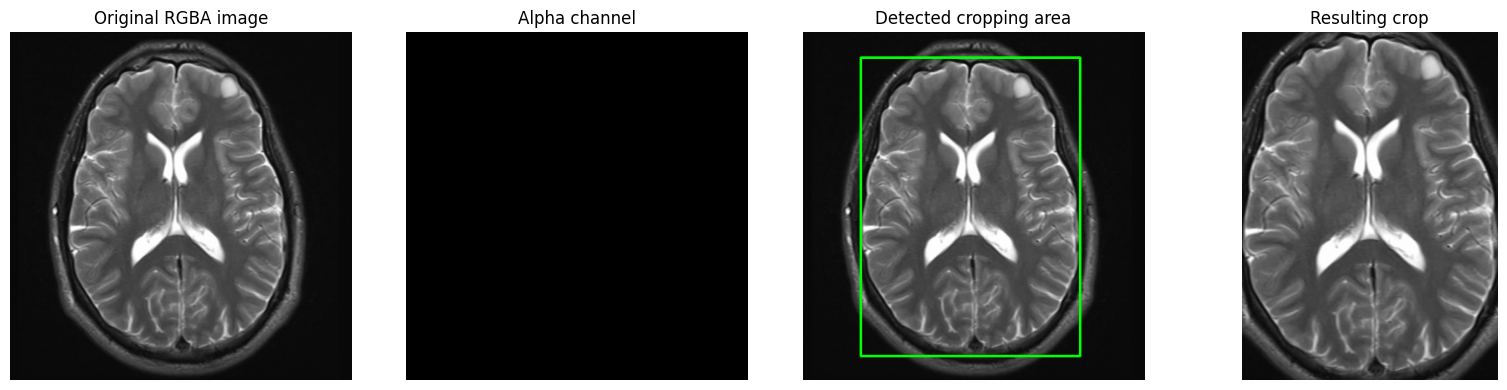


Image 2/3
Training / notumor / Tr-no_22.jpg
Alpha range: 255 to 255
Pixels that are not fully opaque: 0.00%


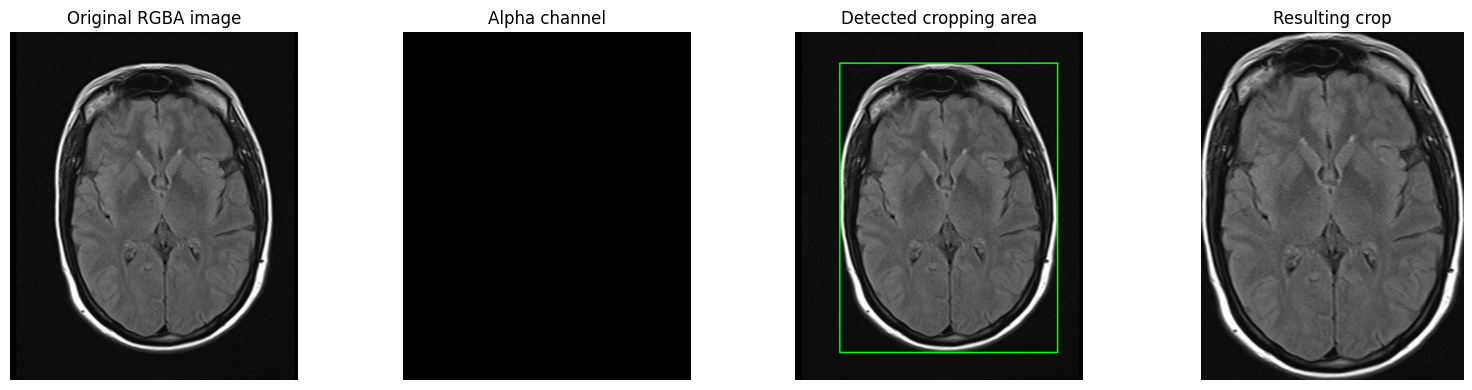


Image 3/3
Training / notumor / Tr-no_572.jpg
Alpha range: 255 to 255
Pixels that are not fully opaque: 0.00%


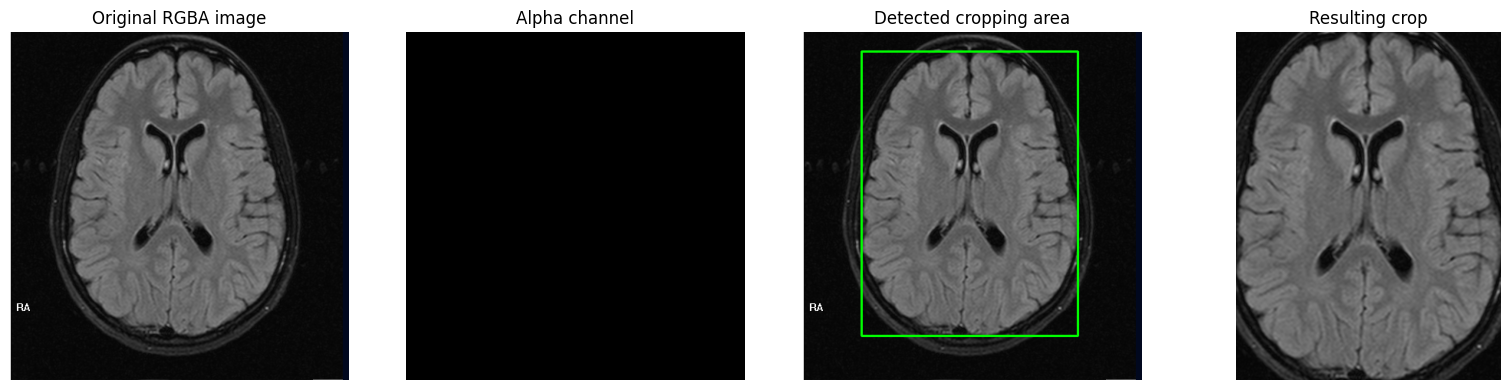

In [24]:
# Inspect all images stored in RGBA mode

import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image


# ---------------------------------------------------------
# 1. Find all RGBA images
# ---------------------------------------------------------

rgba_images = []

for split_folder in [TRAINING_DIR, TESTING_DIR]:
    for class_folder in split_folder.iterdir():

        if class_folder.is_dir():

            for image_path in class_folder.glob("*.jpg"):

                with Image.open(image_path) as img:

                    if img.mode == "RGBA":
                        rgba_images.append(image_path)


print("Total RGBA images:", len(rgba_images))


# ---------------------------------------------------------
# 2. Inspect every RGBA image
# ---------------------------------------------------------

for image_number, image_path in enumerate(
    rgba_images,
    start=1
):

    # Load the original RGBA pixel data with Pillow
    with Image.open(image_path) as img:
        original_rgba = np.array(img.convert("RGBA"))

    # Extract the alpha channel
    alpha_channel = original_rgba[:, :, 3]

    # Calculate how many pixels are not fully opaque
    transparent_pixel_percentage = (
        alpha_channel < 255
    ).mean() * 100

    # Load the image with OpenCV for cropping
    # OpenCV removes the alpha channel here
    image_bgr = cv2.imread(
        str(image_path),
        cv2.IMREAD_COLOR
    )

    if image_bgr is None:
        print("Could not read:", image_path)
        continue

    try:
        cropped_bgr, marked_bgr = crop_img_for_inspection(
            image_bgr
        )

    except Exception as error:
        print("Cropping failed:", image_path)
        print("Error:", error)
        continue

    # Convert OpenCV images from BGR to RGB
    marked_rgb = cv2.cvtColor(
        marked_bgr,
        cv2.COLOR_BGR2RGB
    )

    cropped_rgb = cv2.cvtColor(
        cropped_bgr,
        cv2.COLOR_BGR2RGB
    )

    split_name = image_path.parent.parent.name
    class_name = image_path.parent.name

    print(
        f"\nImage {image_number}/{len(rgba_images)}"
    )

    print(
        f"{split_name} / "
        f"{class_name} / "
        f"{image_path.name}"
    )

    print(
        f"Alpha range: "
        f"{alpha_channel.min()} to "
        f"{alpha_channel.max()}"
    )

    print(
        f"Pixels that are not fully opaque: "
        f"{transparent_pixel_percentage:.2f}%"
    )

    # Display the original, alpha channel and crop
    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(original_rgba)
    plt.title("Original RGBA image")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(alpha_channel, cmap="gray")
    plt.title("Alpha channel")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(marked_rgb)
    plt.title("Detected cropping area")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(cropped_rgb)
    plt.title("Resulting crop")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    plt.close()